Name: Sonal Shinde  
Division: C  
Roll no. 38

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report

## 1. Load Dataset

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (60000, 28, 28)
Test Shape: (10000, 28, 28)


## 2. Data Preprocessing

In [3]:
# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

In [4]:
# Reshape
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

In [5]:
# One-hot Encoding
y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

## 3. Data Visualization

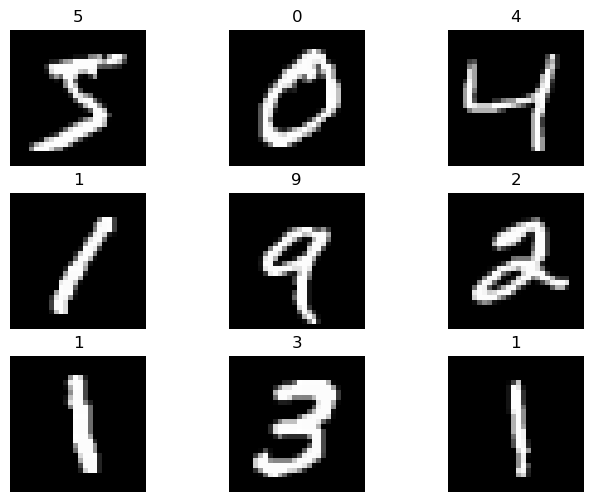

In [6]:
# Sample Images
plt.figure(figsize=(8,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.show()

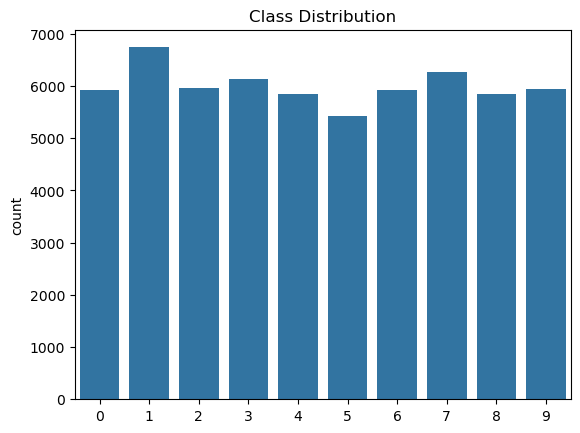

In [7]:
# Class Distribution
sns.countplot(x=y_train)
plt.title("Class Distribution")
plt.show()

## 4. Build CNN Model Function

In [8]:
def build_model(lr=0.001, dropout=0.5, filters=32):

    model = Sequential()

    # Conv Layer 1
    model.add(Conv2D(filters, (3,3), activation='relu', input_shape=(28,28,1)))
    model.add(MaxPooling2D(2,2))

    # Conv Layer 2
    model.add(Conv2D(filters*2, (3,3), activation='relu'))
    model.add(MaxPooling2D(2,2))

    # Flatten
    model.add(Flatten())

    # Dense Layer
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(dropout))

    # Output Layer
    model.add(Dense(10, activation='softmax'))

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

## 5. Train Model

In [9]:
model = build_model()

history = model.fit(
    X_train, y_train_cat,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test_cat)
)

C:\Users\sonal\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 27ms/step - accuracy: 0.8625 - loss: 0.4362 - val_accuracy: 0.9843 - val_loss: 0.0497
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 47s 25ms/step - accuracy: 0.9744 - loss: 0.0871 - val_accuracy: 0.9878 - val_loss: 0.0358
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 30ms/step - accuracy: 0.9805 - loss: 0.0625 - val_accuracy: 0.9891 - val_loss: 0.0309
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 71s 38ms/step - accuracy: 0.9858 - loss: 0.0473 - val_accuracy: 0.9896 - val_loss: 0.0297
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 32ms/step - accuracy: 0.9880 - loss: 0.0375 - val_accuracy: 0.9905 - val_loss: 0.0297


## 6. Evaluate Model

In [10]:
loss, accuracy = model.evaluate(X_test, y_test_cat)
print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9876 - loss: 0.0379
Accuracy: 0.9904999732971191


## 7. Predictions

In [11]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


## 8. Confusion Matrix

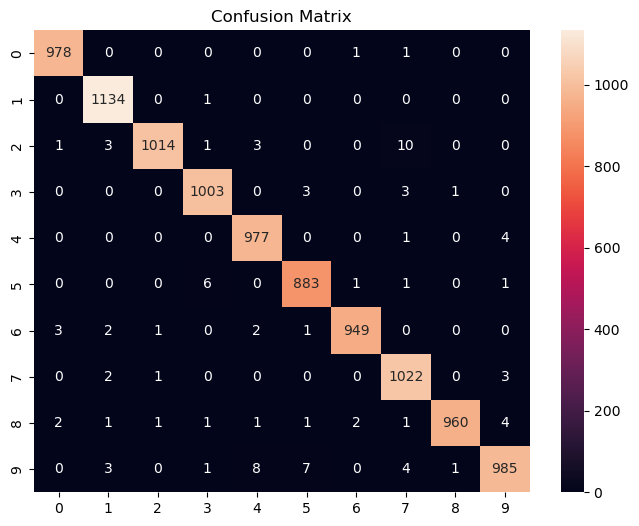

In [12]:
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

## 9. Accuracy Graph

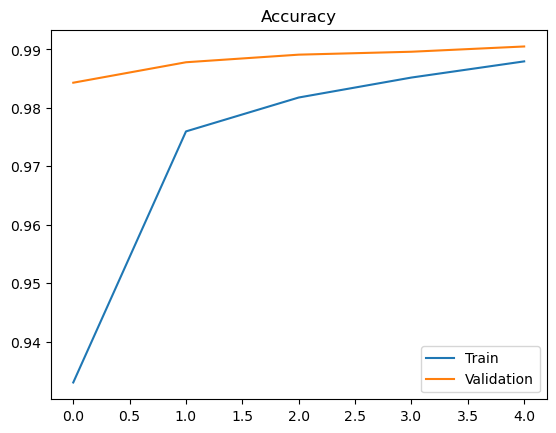

In [13]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Accuracy")
plt.show()

## 10. Loss Graph

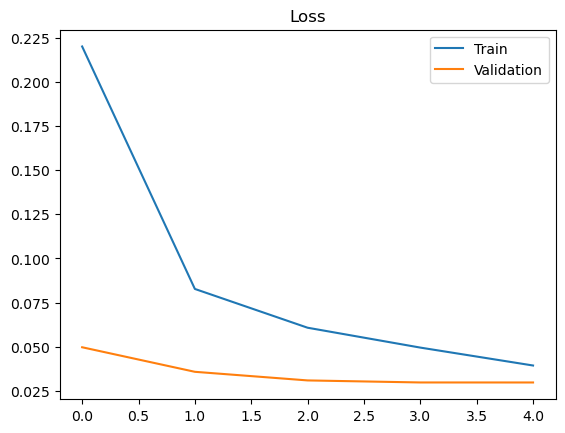

In [16]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.legend()
plt.title("Loss")
plt.show()

## 11. Hyperparameter Tuning

In [17]:
# Learning Rate
for lr in [0.01, 0.001, 0.0001]:
    print("LR:", lr)
    model = build_model(lr=lr)
    model.fit(X_train, y_train_cat, epochs=3, verbose=0)
    print("Accuracy:", model.evaluate(X_test, y_test_cat, verbose=0)[1])

LR: 0.01
Accuracy: 0.9768999814987183
LR: 0.001
Accuracy: 0.9904000163078308
LR: 0.0001
Accuracy: 0.9821000099182129


In [18]:
# Dropout
for d in [0.3, 0.5, 0.7]:
    print("Dropout:", d)
    model = build_model(dropout=d)
    model.fit(X_train, y_train_cat, epochs=3, verbose=0)
    print("Accuracy:", model.evaluate(X_test, y_test_cat, verbose=0)[1])

Dropout: 0.3
Accuracy: 0.9901999831199646
Dropout: 0.5
Accuracy: 0.9901999831199646
Dropout: 0.7
Accuracy: 0.989300012588501


In [25]:
## Filters
for f in [32, 64]:
    print("Filters:", f)
    model = build_model(filters=f)
    model.fit(X_train, y_train_cat, epochs=3, verbose=0)
    print("Accuracy:", model.evaluate(X_test, y_test_cat, verbose=0)[1])

Filters: 32
Accuracy: 0.9891999959945679
Filters: 64
Accuracy: 0.9901999831199646


## 12. Misclassified Images

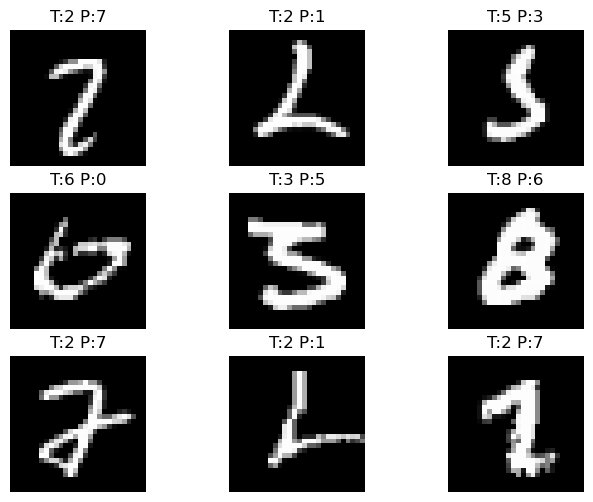

In [26]:
mis = np.where(y_test != y_pred_classes)[0]

plt.figure(figsize=(8,6))
for i, idx in enumerate(mis[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"T:{y_test[idx]} P:{y_pred_classes[idx]}")
    plt.axis('off')
plt.show()